# 02 - Apache Spark : Main Analysis

The heavy lifting already happened in `01_data_preprocessing.ipynb`. Here we read the
**Parquet** files and run distributed analytics with PySpark **DataFrame API** and
**Spark SQL**, then push only the small aggregated results to Pandas for plotting.

Goals:
- Aggregations (`groupBy`, `agg`) over 1.5M traffic records
- SQL queries via temporary views
- **Join** traffic_data <-> area_monitor on `area_id`
- **Window functions** (moving averages, ranking)
- Pivot tables
- Matplotlib visualizations (on aggregated samples)


## 1. Session & Load Parquet

In [1]:
# 1. Spark session + read preprocessed parquet
from pyspark.sql import SparkSession, functions as fn, Window
import os

spark = SparkSession.builder.appName("traffic_analysis").master("local[*]").getOrCreate()
spark.sparkContext.setLogLevel("WARN")

# Resolve paths so the notebook works from any launch folder
ROOT = os.path.abspath(".") if os.path.isdir("data") else os.path.abspath("..")
DATA_DIR = os.path.join(ROOT, "data")
PROCESSED_DIR = os.path.join(DATA_DIR, "processed")
OUTPUT_DIR = os.path.join(ROOT, "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

traffic = spark.read.parquet(os.path.join(PROCESSED_DIR, "traffic_clean.parquet"))
monitor = spark.read.parquet(os.path.join(PROCESSED_DIR, "area_monitor_clean.parquet"))

print("traffic rows :", traffic.count())
print("monitor rows :", monitor.count())
print()
traffic.printSchema()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/08/09 22:59:43 WARN Utils: Your hostname, pop-os, resolves to a loopback address: 127.0.0.1; using 172.20.10.7 instead (on interface wlp0s20f3)
26/08/09 22:59:43 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


/home/heet18/Coding-Workspace/Futuristic/Heet/Github/Projects/Python-DataScience/myenv/lib/python3.12/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/08/09 22:59:44 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


traffic rows : 1500000
monitor rows : 750014

root
 |-- event_id: integer (nullable = true)
 |-- area_id: integer (nullable = true)
 |-- road_id: string (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- date: date (nullable = true)
 |-- hour: integer (nullable = true)
 |-- vehicle_type: string (nullable = true)
 |-- speed_kmh: double (nullable = true)
 |-- traffic_volume: integer (nullable = true)
 |-- weather_condition: string (nullable = true)
 |-- congestion_level: string (nullable = true)
 |-- day_of_week: string (nullable = true)
 |-- time_of_day: string (nullable = true)
 |-- speed_category: string (nullable = true)



## 2. SQL Views

In [2]:
# 2. Register temp views for Spark SQL
traffic.createOrReplaceTempView("traffic")
monitor.createOrReplaceTempView("monitor")

spark.sql("SELECT * FROM traffic LIMIT 5").show(truncate=False)

+--------+-------+-------+-------------------+----------+----+------------+---------+--------------+-----------------+----------------+-----------+-----------+--------------+
|event_id|area_id|road_id|timestamp          |date      |hour|vehicle_type|speed_kmh|traffic_volume|weather_condition|congestion_level|day_of_week|time_of_day|speed_category|
+--------+-------+-------+-------------------+----------+----+------------+---------+--------------+-----------------+----------------+-----------+-----------+--------------+
|1       |78     |R019   |2024-03-20 09:32:36|2024-03-20|9   |truck       |67.4     |95            |clear            |low             |Wednesday  |morning    |fast          |
|4       |44     |R027   |2024-01-01 09:58:49|2024-01-01|9   |car         |38.5     |421           |cloudy           |high            |Monday     |morning    |moderate      |
|5       |86     |R029   |2024-02-25 03:21:37|2024-02-25|3   |auto        |21.1     |218           |rain             |medium 

## 3. Aggregations

### 3.1 Average speed & volume by area (DataFrame API)

In [3]:
# 3.1 Aggregations
area_stats = (
    traffic.groupBy("area_id")
    .agg(
        fn.round(fn.avg("speed_kmh"), 1).alias("avg_speed"),
        fn.sum("traffic_volume").alias("total_volume"),
        fn.count("event_id").alias("event_count"),
    )
    .orderBy(fn.col("total_volume").desc())
)
area_stats.show(10)

+-------+---------+------------+-----------+
|area_id|avg_speed|total_volume|event_count|
+-------+---------+------------+-----------+
|     62|     54.9|     3830314|      15322|
|     99|     54.9|     3818730|      15263|
|     52|     55.2|     3814659|      15292|
|     41|     55.4|     3811476|      15206|
|     29|     54.9|     3805887|      15226|
|     12|     55.2|     3798470|      15216|
|     69|     55.2|     3790808|      15043|
|     44|     55.2|     3786068|      15155|
|     88|     55.2|     3783417|      15127|
|     93|     55.2|     3782634|      15267|
+-------+---------+------------+-----------+
only showing top 10 rows


### 3.2 Top congested areas by SQL

In [4]:
# 3.2 Spark SQL
spark.sql("""
    SELECT area_id,
           ROUND(AVG(speed_kmh), 1) AS avg_speed,
           SUM(traffic_volume)      AS total_volume
    FROM traffic
    GROUP BY area_id
    ORDER BY avg_speed ASC
    LIMIT 10
""").show()

+-------+---------+------------+
|area_id|avg_speed|total_volume|
+-------+---------+------------+
|     26|     54.6|     3752706|
|     38|     54.7|     3765710|
|     50|     54.8|     3769859|
|     30|     54.8|     3707887|
|     57|     54.9|     3752804|
|     48|     54.9|     3741409|
|      3|     54.9|     3748554|
|     43|     54.9|     3779614|
|     65|     54.9|     3684073|
|     62|     54.9|     3830314|
+-------+---------+------------+



### 3.3 Hourly traffic profile

In [5]:
# 3.3 Traffic volume by hour
hourly = (
    traffic.groupBy("hour")
    .agg(fn.round(fn.avg("traffic_volume"), 1).alias("avg_volume"),
         fn.avg("speed_kmh").alias("avg_speed"))
    .orderBy("hour")
)
hourly.show(10)

+----+----------+------------------+
|hour|avg_volume|         avg_speed|
+----+----------+------------------+
|   0|     249.9| 55.04306848084202|
|   1|     249.5| 55.31501580019566|
|   2|     249.0| 55.18193001465997|
|   3|     249.6| 55.13247535509438|
|   4|     250.1| 55.11651187783713|
|   5|     249.7|55.104174743283785|
|   6|     248.6| 55.12639304591487|
|   7|     249.6| 54.92219629176582|
|   8|     248.9|55.032680473658026|
|   9|     248.7| 55.15628544877754|
+----+----------+------------------+
only showing top 10 rows


## 4. Joins

### 4.1 Enrich traffic with area metadata

In [6]:
# 4.1 Inner join on area_id
enriched = traffic.join(monitor, "area_id")

print("Enriched rows:", enriched.count())
enriched.select("event_id", "area_id", "city", "speed_kmh", "traffic_volume") \
        .show(5, truncate=False)

# What fraction of traffic rows have no matching area?
no_match = traffic.join(monitor, "area_id", "left_anti").count()
print("Traffic rows without an area match:", no_match)

Enriched rows: 11250249384


+--------+-------+---------+---------+--------------+
|event_id|area_id|city     |speed_kmh|traffic_volume|
+--------+-------+---------+---------+--------------+
|1499595 |33     |Bengaluru|63.3     |478           |
|1499244 |33     |Bengaluru|57.1     |99            |
|1499207 |33     |Bengaluru|32.6     |113           |
|1498647 |33     |Bengaluru|55.7     |22            |
|1498579 |33     |Bengaluru|55.7     |105           |
+--------+-------+---------+---------+--------------+
only showing top 5 rows


Traffic rows without an area match: 0


### 4.2 City-level summary

In [7]:
# 4.2 Group after join
city_stats = (
    enriched.groupBy("city")
    .agg(fn.round(fn.avg("speed_kmh"), 1).alias("avg_speed"),
         fn.sum("traffic_volume").alias("total_volume"),
         fn.countDistinct("area_id").alias("areas"))
    .orderBy(fn.col("total_volume").desc())
)
city_stats.show()

+---------+---------+------------+-----+
|     city|avg_speed|total_volume|areas|
+---------+---------+------------+-----+
|     Pune|     55.1|562786813936|   20|
|    Delhi|     55.2|562343610617|   20|
|Bengaluru|     55.0|562082979600|   20|
|   Mumbai|     55.1|559840273874|   20|
|Ahmedabad|     55.1|558592508060|   20|
+---------+---------+------------+-----+



## 5. Window Functions

### 5.1 Ranking - most congested area per day

In [8]:
# 5.1 Rank areas by congestion within each day
w = Window.partitionBy("date").orderBy(fn.col("traffic_volume").desc())

ranked = traffic.select(
    "date", "area_id", "traffic_volume",
    fn.row_number().over(w).alias("rank_in_day")
)
ranked.filter("rank_in_day <= 3").show(15, truncate=False)

+----------+-------+--------------+-----------+
|date      |area_id|traffic_volume|rank_in_day|
+----------+-------+--------------+-----------+
|2024-01-01|69     |499           |1          |
|2024-01-01|83     |499           |2          |
|2024-01-01|60     |499           |3          |
|2024-01-02|71     |499           |1          |
|2024-01-02|89     |499           |2          |
|2024-01-02|42     |499           |3          |
|2024-01-03|73     |499           |1          |
|2024-01-03|47     |499           |2          |
|2024-01-03|71     |499           |3          |
|2024-01-04|81     |499           |1          |
|2024-01-04|67     |499           |2          |
|2024-01-04|78     |499           |3          |
|2024-01-05|72     |499           |1          |
|2024-01-05|8      |499           |2          |
|2024-01-05|9      |499           |3          |
+----------+-------+--------------+-----------+
only showing top 15 rows


### 5.2 Moving average of speed (7-day window per area)

In [9]:
# 5.2 Rolling 7-row moving average of daily avg speed per area
daily = (
    traffic.groupBy("area_id", "date")
    .agg(fn.avg("speed_kmh").alias("day_speed"))
)

w2 = Window.partitionBy("area_id").orderBy("date").rowsBetween(-6, 0)
moving = daily.withColumn(
    "ma7_speed", fn.round(fn.avg("day_speed").over(w2), 2)
)
moving.filter("area_id = 1").orderBy("date").show(10)

+-------+----------+------------------+---------+
|area_id|      date|         day_speed|ma7_speed|
+-------+----------+------------------+---------+
|      1|2024-01-01|53.964670658682635|    53.96|
|      1|2024-01-02|55.024203821656045|    54.49|
|      1|2024-01-03| 52.99943820224719|     54.0|
|      1|2024-01-04|  54.3520618556701|    54.09|
|      1|2024-01-05| 54.55454545454544|    54.18|
|      1|2024-01-06| 54.97916666666667|    54.31|
|      1|2024-01-07| 54.00404624277457|    54.27|
|      1|2024-01-08| 55.62923976608186|    54.51|
|      1|2024-01-09| 52.32372881355932|    54.12|
|      1|2024-01-10| 56.48322981366459|    54.62|
+-------+----------+------------------+---------+
only showing top 10 rows


## 6. Pivot - traffic volume by hour x day_of_week

In [10]:
# 6. Pivot hourly volume across weekdays
pivot = (
    traffic.groupBy("hour")
    .pivot("day_of_week", ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
    .agg(fn.round(fn.avg("traffic_volume"), 1))
    .orderBy("hour")
)
pivot.show(24, truncate=False)

+----+------+-------+---------+--------+------+--------+------+
|hour|Monday|Tuesday|Wednesday|Thursday|Friday|Saturday|Sunday|
+----+------+-------+---------+--------+------+--------+------+
|0   |248.4 |249.4  |250.0    |253.0   |247.6 |251.6   |249.0 |
|1   |250.9 |248.4  |247.6    |249.9   |249.5 |250.0   |250.2 |
|2   |246.1 |248.7  |247.1    |249.5   |251.0 |250.9   |249.7 |
|3   |250.7 |248.5  |249.2    |248.8   |251.1 |248.4   |250.2 |
|4   |248.8 |251.6  |251.0    |251.4   |248.4 |249.7   |250.0 |
|5   |250.4 |247.8  |248.6    |252.1   |250.1 |249.8   |248.7 |
|6   |249.2 |246.3  |249.9    |249.4   |248.2 |248.7   |248.4 |
|7   |248.9 |250.0  |250.3    |249.8   |248.9 |252.2   |246.9 |
|8   |248.9 |249.9  |247.7    |248.3   |249.3 |250.0   |247.9 |
|9   |251.3 |248.1  |247.4    |246.8   |249.4 |249.4   |248.5 |
|10  |248.7 |251.3  |251.4    |253.1   |248.2 |253.0   |248.3 |
|11  |247.9 |249.0  |248.6    |249.4   |250.6 |252.0   |248.7 |
|12  |248.6 |248.8  |248.6    |252.3   |

## 7. Push to Pandas & Visualize

Only the small aggregated results (hundreds of rows) are moved to Pandas for plotting.

In [11]:
# 7.1 Convert small results to Pandas
hourly_pd = hourly.toPandas()
city_pd   = city_stats.toPandas()
area_pd   = area_stats.limit(15).toPandas()
print("Pandas frames ready:", hourly_pd.shape, city_pd.shape, area_pd.shape)

/home/heet18/Coding-Workspace/Futuristic/Heet/Github/Projects/Python-DataScience/myenv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


/home/heet18/Coding-Workspace/Futuristic/Heet/Github/Projects/Python-DataScience/myenv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


/home/heet18/Coding-Workspace/Futuristic/Heet/Github/Projects/Python-DataScience/myenv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Pandas frames ready: (24, 3) (5, 4) (15, 4)


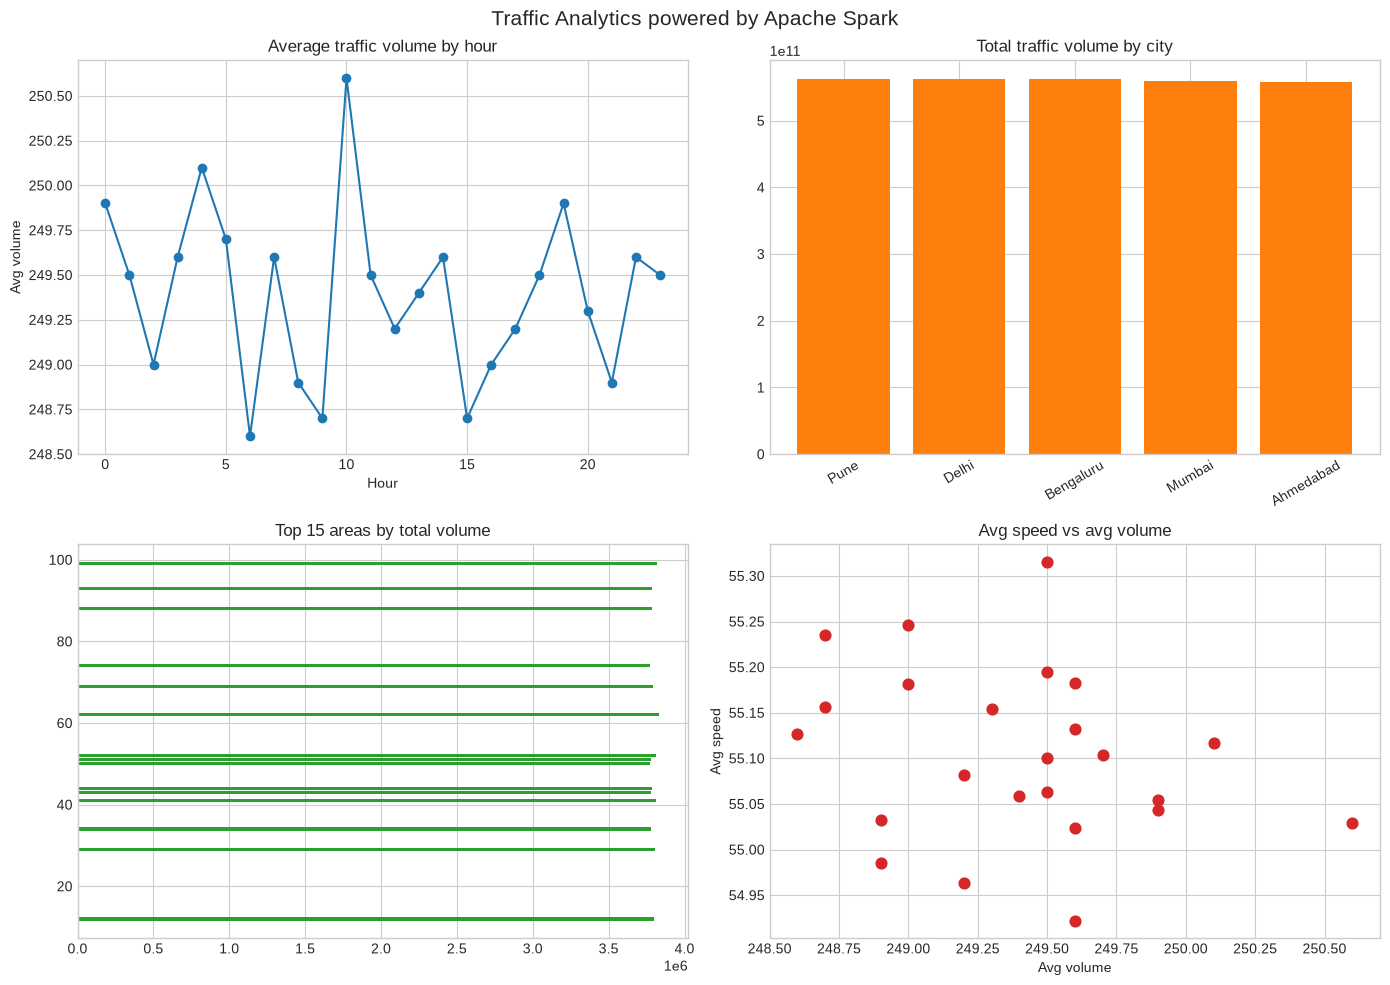

Saved figure to /home/heet18/Coding-Workspace/Futuristic/Heet/Github/Projects/Python-DataScience/apache_spark/outputs/analysis_plots.png


In [12]:
# 7.2 Imports & style
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Traffic Analytics powered by Apache Spark", fontsize=15)

# (a) Hourly volume profile
axes[0, 0].plot(hourly_pd["hour"], hourly_pd["avg_volume"], marker="o", color="#1f77b4")
axes[0, 0].set_title("Average traffic volume by hour")
axes[0, 0].set_xlabel("Hour"); axes[0, 0].set_ylabel("Avg volume")

# (b) City-level totals
axes[0, 1].bar(city_pd["city"], city_pd["total_volume"], color="#ff7f0e")
axes[0, 1].set_title("Total traffic volume by city")
axes[0, 1].tick_params(axis="x", rotation=30)

# (c) Top areas by volume
axes[1, 0].barh(area_pd["area_id"][::-1], area_pd["total_volume"][::-1], color="#2ca02c")
axes[1, 0].set_title("Top 15 areas by total volume")

# (d) Speed vs volume scatter
sample = hourly_pd
axes[1, 1].scatter(sample["avg_volume"], sample["avg_speed"], s=60, color="#d62728")
axes[1, 1].set_title("Avg speed vs avg volume")
axes[1, 1].set_xlabel("Avg volume"); axes[1, 1].set_ylabel("Avg speed")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "analysis_plots.png"), dpi=120, bbox_inches="tight")
plt.show()
print("Saved figure to", os.path.join(OUTPUT_DIR, "analysis_plots.png"))

## 8. Save Final Results

Write the enriched, aggregated tables back out so the whole pipeline is reproducible.

In [13]:
# 8. Persist results (coalesce to a single file per result)
city_stats.coalesce(1).write.mode("overwrite").csv(os.path.join(OUTPUT_DIR, "city_stats.csv"), header=True)
area_stats.coalesce(1).write.mode("overwrite").csv(os.path.join(OUTPUT_DIR, "area_stats.csv"), header=True)
pivot.coalesce(1).write.mode("overwrite").csv(os.path.join(OUTPUT_DIR, "hour_weekday_pivot.csv"), header=True)
print("Results written under", OUTPUT_DIR)

Results written under /home/heet18/Coding-Workspace/Futuristic/Heet/Github/Projects/Python-DataScience/apache_spark/outputs


## Summary

All heavy computation (aggregations, joins, window functions, pivots over **1.5M**
rows) ran in-memory on Spark's distributed engine. Only the tiny results were pulled
into Pandas for plotting - this is the correct pattern for large data.

> **Next steps:** increase parallelism with a cluster (`spark://...`), try `spark-sql`,
> or run MLlib (`spark.ml`) models on the cleaned features.

In [14]:
spark.stop()
print("Spark session stopped.")

Spark session stopped.
